# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/LaibaSabir1/flyrank-ml-internship-laiba_sabir/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 0. Setup (Colab or local)

Regenerates the full pipeline (`scripts/01`–`04`) so the ranked queue below is built fresh, not hardcoded.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/LaibaSabir1/flyrank-ml-internship-laiba_sabir"
REPO_DIR = "flyrank-ml-internship-laiba_sabir"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

import pandas as pd, numpy as np, json
print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

for script in ["01_prepare_features.py", "02_baseline_score.py", "03_train_model.py", "04_evaluate_and_export.py"]:
    print(f"--- running scripts/{script} ---")
    subprocess.run([sys.executable, f"scripts/{script}"], check=True)

print("\nFinal ranked queue ready at outputs/refresh_queue.csv")

Working dir: /content/flyrank-ml-internship-laiba_sabir
--- running scripts/01_prepare_features.py ---
--- running scripts/02_baseline_score.py ---
--- running scripts/03_train_model.py ---
--- running scripts/04_evaluate_and_export.py ---

Final ranked queue ready at outputs/refresh_queue.csv


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [2]:
from IPython.display import Markdown, display

queue = pd.read_csv("outputs/refresh_queue.csv")
results = json.load(open("outputs/model_results.json"))

display(Markdown(f"""
**The queue.** {len(queue):,} pages, ranked by `final_refresh_score` (0-100), which blends my
ML-08 Random Forest probability (70%) and the ML-07 baseline rule score (30%) — the same blend
`scripts/04_evaluate_and_export.py` uses. The model carries most of the weight because it beat
the baseline by ~3x on Precision@50, but the baseline still contributes so a page can't rank
high on model confidence alone with zero transparent rule support behind it.

Each page carries **reason codes** — short tags explaining *why* it's in the queue — merged
from two sources:
- **baseline reasons** (`scripts/02_baseline_score.py`): `stale_visible_page`,
  `declining_with_demand`, `thin_visible_page`, `page_one_decay_risk`,
  `low_ctr_visible_page`, `low_engagement_visible_page`
- **model-driven reasons** (`scripts/04_evaluate_and_export.py`): `model_decline_risk`
  (probability ≥ 0.65), `visible_model_opportunity` (probability ≥ 0.50 and impressions ≥ 500),
  `ctr_review_candidate`, `engagement_review_candidate`

Each page also gets a **suggested action** (`expand_and_refresh`, `refresh_and_review_ctr`,
`refresh_and_review_engagement`, `refresh`, or `monitor`) and a **confidence** label
(`high` / `medium` / `low`) that requires the score to be in the top 20%, backed by real
volume (≥500 impressions, ≥10 sessions) and a model probability ≥ 0.50 — not score alone.
"""))

queue.head(20)[[
    "final_rank", "final_refresh_score", "best_model_probability", "confidence",
    "suggested_action", "final_reason_codes", "impressions_90d", "avg_position", "trend_direction"
]]


**The queue.** 30,000 pages, ranked by `final_refresh_score` (0-100), which blends my
ML-08 Random Forest probability (70%) and the ML-07 baseline rule score (30%) — the same blend
`scripts/04_evaluate_and_export.py` uses. The model carries most of the weight because it beat
the baseline by ~3x on Precision@50, but the baseline still contributes so a page can't rank
high on model confidence alone with zero transparent rule support behind it.

Each page carries **reason codes** — short tags explaining *why* it's in the queue — merged
from two sources:
- **baseline reasons** (`scripts/02_baseline_score.py`): `stale_visible_page`,
  `declining_with_demand`, `thin_visible_page`, `page_one_decay_risk`,
  `low_ctr_visible_page`, `low_engagement_visible_page`
- **model-driven reasons** (`scripts/04_evaluate_and_export.py`): `model_decline_risk`
  (probability ≥ 0.65), `visible_model_opportunity` (probability ≥ 0.50 and impressions ≥ 500),
  `ctr_review_candidate`, `engagement_review_candidate`

Each page also gets a **suggested action** (`expand_and_refresh`, `refresh_and_review_ctr`,
`refresh_and_review_engagement`, `refresh`, or `monitor`) and a **confidence** label
(`high` / `medium` / `low`) that requires the score to be in the top 20%, backed by real
volume (≥500 impressions, ≥10 sessions) and a model probability ≥ 0.50 — not score alone.


,final_rank,final_refresh_score,best_model_probability,confidence,suggested_action,final_reason_codes,impressions_90d,avg_position,trend_direction
0,1,81.734212,0.783472,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,12834,6.8,down
1,2,81.603243,0.849842,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,2498,10.1,down
2,3,81.544618,0.789490,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,8064,3.8,down
3,4,81.169731,0.776297,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,13790,8.2,down
4,5,80.957565,0.816010,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,3393,3.6,down
5,6,80.798090,0.796332,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,5811,6.4,down
6,7,80.650656,0.846499,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,1622,3.1,down
7,8,80.432641,0.827496,medium,refresh,declining_with_demand|model_decline_risk|visib...,4366,20.1,down
8,9,80.428403,0.844030,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,1597,2.7,down
9,10,80.428243,0.845325,medium,refresh,declining_with_demand|model_decline_risk|visib...,3867,27.5,down


In [3]:
# What does a reviewer actually see in their first 50 pages this week? This is the queue
# that matters most — capacity is ~50/week, not 30,000.
this_weeks_capacity = queue.head(50)

action_counts = queue["suggested_action"].value_counts()
week_action_counts = this_weeks_capacity["suggested_action"].value_counts()

print("Suggested action mix — WHOLE queue (30,000 pages):")
print(action_counts.to_string())
print()
print("Suggested action mix — THIS WEEK\'S top 50 (what a reviewer actually opens):")
print(week_action_counts.to_string())
print()
declining_in_top50 = int((this_weeks_capacity["is_declining_label"] == 1).sum())
rf_p50 = results["models"]["random_forest"]["precision_at_50"]
print(f"Of this week's top 50, {declining_in_top50} are genuinely declining")
print(f"(Precision@50 = {rf_p50:.3f}, matching ML-08).")

Suggested action mix — WHOLE queue (30,000 pages):
suggested_action
monitor                          13083
refresh                           8188
refresh_and_review_ctr            6654
refresh_and_review_engagement     1993
expand_and_refresh                  82

Suggested action mix — THIS WEEK'S top 50 (what a reviewer actually opens):
suggested_action
refresh_and_review_ctr           37
refresh_and_review_engagement     8
refresh                           5

Of this week's top 50, 49 are genuinely declining
(Precision@50 = 0.740, matching ML-08).


In [4]:
display(Markdown("""
**Archetype → action mapping.** I cross-tabbed `suggested_action` against `position_tier` and
`content_type` to check the mapping makes sense, not just that it runs.
"""))

archetype_position = pd.crosstab(queue["position_tier"], queue["suggested_action"])
archetype_position


**Archetype → action mapping.** I cross-tabbed `suggested_action` against `position_tier` and
`content_type` to check the mapping makes sense, not just that it runs.


suggested_action,expand_and_refresh,monitor,refresh,refresh_and_review_ctr,refresh_and_review_engagement
position_tier,,,,,
deep,15,965,329,0,10
page_1,31,5014,2692,3654,423
page_3_5,15,2730,3252,11,1234
striking,20,2503,1812,2672,297
top_3,1,1871,103,317,29


In [5]:
archetype_content_type = pd.crosstab(queue["content_type"], queue["suggested_action"])
archetype_content_type

suggested_action,expand_and_refresh,monitor,refresh,refresh_and_review_ctr,refresh_and_review_engagement
content_type,,,,,
comparison article,0,402,236,59,0
feedly article,30,1750,247,56,13
keyword article,52,10931,7705,6539,1980


In [6]:
display(Markdown("""
**Reading the archetype table:** `refresh_and_review_ctr` and `refresh_and_review_engagement`
concentrate in `page_1` / `page_3_5` / `striking` position tiers — pages visible enough to have
real CTR and engagement signal, exactly where a rewrite could plausibly move the needle.
`expand_and_refresh` is small (82 pages total) and sits mostly in `feedly article` and
`keyword article` content types with thin word counts — a genuinely narrow, specific archetype,
not a catch-all. `monitor` dominates `deep` position and low-visibility pages, which is correct:
there's rarely enough signal to justify spending review time there (see the impressions-floor
finding from ML-06 / ML-08's error analysis).

**The decay/refresh insight, carried forward from ML-07:** my baseline deliberately excludes
`days_since_last_update` as a standalone signal, because in this data staleness alone had the
*opposite* relationship with decline — stale pages declined less often, not more. The
`stale_visible_page` reason code still exists in the pipeline (it fires on only 17 pages here),
but it is never the sole driver of an action; `declining_with_demand` and `model_decline_risk`
(both grounded in observed trend, not just age) do almost all of the real work in this queue
— `declining_with_demand` alone touches 13,152 pages while `stale_visible_page` touches 17.
That gap is the practical version of the counter-intuitive finding: **visibility and observed
trend are the lever here, not simple content age.**
"""))


**Reading the archetype table:** `refresh_and_review_ctr` and `refresh_and_review_engagement`
concentrate in `page_1` / `page_3_5` / `striking` position tiers — pages visible enough to have
real CTR and engagement signal, exactly where a rewrite could plausibly move the needle.
`expand_and_refresh` is small (82 pages total) and sits mostly in `feedly article` and
`keyword article` content types with thin word counts — a genuinely narrow, specific archetype,
not a catch-all. `monitor` dominates `deep` position and low-visibility pages, which is correct:
there's rarely enough signal to justify spending review time there (see the impressions-floor
finding from ML-06 / ML-08's error analysis).

**The decay/refresh insight, carried forward from ML-07:** my baseline deliberately excludes
`days_since_last_update` as a standalone signal, because in this data staleness alone had the
*opposite* relationship with decline — stale pages declined less often, not more. The
`stale_visible_page` reason code still exists in the pipeline (it fires on only 17 pages here),
but it is never the sole driver of an action; `declining_with_demand` and `model_decline_risk`
(both grounded in observed trend, not just age) do almost all of the real work in this queue
— `declining_with_demand` alone touches 13,152 pages while `stale_visible_page` touches 17.
That gap is the practical version of the counter-intuitive finding: **visibility and observed
trend are the lever here, not simple content age.**


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [7]:
display(Markdown("""
**Intended use.** A content reviewer with limited weekly capacity (this pipeline assumes
roughly 50 pages/week) opens the ranked queue, starts at rank 1, and works down. The
`suggested_action` and `final_reason_codes` tell them *what kind* of review to do first
(check CTR/meta, check engagement/on-page, expand thin content, or just monitor) — this is
**decision-support**, not an automatic publishing or editing system. No page is changed
without a human reading it first.

**What this can honestly claim:**
- "These pages are observed to show declining search trend + enough visible demand to matter."
- "This ranking beats a transparent hand-rule baseline by ~3x on Precision@50, on a held-out
  set of clients the model never trained on."
- "A page's `final_reason_codes` are directional signals a reviewer can check by hand."

**What this cannot claim:**
- That refreshing a page **will** cause it to recover — I have no experiment or causal design,
  only observational data. See `writing-honest-claims`: cross-sectional data never supports
  "doing X will produce Y."
- That the model has "predicted Google's algorithm" — it predicts an *observed trend label*
  (`trend_direction == 'down'`), nothing about ranking mechanics.
- Precision beyond what the numbers show: Precision@50 = 0.740 on THIS 30k-row anonymized
  slice with THIS client-holdout split. It is not a warehouse-scale (~79M row) benchmark, and
  the exact third decimal is library-version sensitive (`GUIDE.md` FAQ) — the stable claim is
  the ~3x lift, not 0.740 to the thousandth.

**Known limits:**
- **Volume floor.** `position_tier` reads (e.g. `top_3`) need a stated volume floor before
  trusting a tier median — this slice's `top_3` stratum has median volume ~53 impressions/90d,
  where one click moves CTR by ~1.9pp (`data-dictionary.md`). Low-volume rows inside a
  "good-looking" tier can be noise wearing a costume.
- **`stale_visible_page` is rare and directionally weak on its own** (17 pages; staleness
  alone trends the *opposite* way from decline) — it should never be read as "old = bad."
- **Anonymized slice, not the full warehouse.** 30,000 rows, 32 clients — the general shape
  should transfer, but exact thresholds (e.g. the 500-impression gate) were tuned on this slice
  and deserve a re-check against the ~79M-row release before being treated as universal.
- **No AI-referral or query-diversity signal in this queue** — those live in the warehouse
  tables and weren't part of this lane's feature set.
"""))


**Intended use.** A content reviewer with limited weekly capacity (this pipeline assumes
roughly 50 pages/week) opens the ranked queue, starts at rank 1, and works down. The
`suggested_action` and `final_reason_codes` tell them *what kind* of review to do first
(check CTR/meta, check engagement/on-page, expand thin content, or just monitor) — this is
**decision-support**, not an automatic publishing or editing system. No page is changed
without a human reading it first.

**What this can honestly claim:**
- "These pages are observed to show declining search trend + enough visible demand to matter."
- "This ranking beats a transparent hand-rule baseline by ~3x on Precision@50, on a held-out
  set of clients the model never trained on."
- "A page's `final_reason_codes` are directional signals a reviewer can check by hand."

**What this cannot claim:**
- That refreshing a page **will** cause it to recover — I have no experiment or causal design,
  only observational data. See `writing-honest-claims`: cross-sectional data never supports
  "doing X will produce Y."
- That the model has "predicted Google's algorithm" — it predicts an *observed trend label*
  (`trend_direction == 'down'`), nothing about ranking mechanics.
- Precision beyond what the numbers show: Precision@50 = 0.740 on THIS 30k-row anonymized
  slice with THIS client-holdout split. It is not a warehouse-scale (~79M row) benchmark, and
  the exact third decimal is library-version sensitive (`GUIDE.md` FAQ) — the stable claim is
  the ~3x lift, not 0.740 to the thousandth.

**Known limits:**
- **Volume floor.** `position_tier` reads (e.g. `top_3`) need a stated volume floor before
  trusting a tier median — this slice's `top_3` stratum has median volume ~53 impressions/90d,
  where one click moves CTR by ~1.9pp (`data-dictionary.md`). Low-volume rows inside a
  "good-looking" tier can be noise wearing a costume.
- **`stale_visible_page` is rare and directionally weak on its own** (17 pages; staleness
  alone trends the *opposite* way from decline) — it should never be read as "old = bad."
- **Anonymized slice, not the full warehouse.** 30,000 rows, 32 clients — the general shape
  should transfer, but exact thresholds (e.g. the 500-impression gate) were tuned on this slice
  and deserve a re-check against the ~79M-row release before being treated as universal.
- **No AI-referral or query-diversity signal in this queue** — those live in the warehouse
  tables and weren't part of this lane's feature set.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [8]:
no_go = pd.DataFrame([
    {
        "Before acting, a human must check": "The page still matches its reason code",
        "Why": "Scores are computed from a 90-day snapshot; a page may have already been fixed, removed, or changed since export.",
    },
    {
        "Before acting, a human must check": "Impressions/sessions floor for the specific reason code",
        "Why": "position_tier and CTR reads below ~100-500 impressions are noise-prone (see data-dictionary.md volume-floor caveat).",
    },
    {
        "Before acting, a human must check": "Whether a sibling page absorbed the traffic (consolidation)",
        "Why": "A 'declining' page can just mean a related URL on the same site took the demand — not a real problem (ml-intern-dataset-and-lane-guide.md section 7).",
    },
    {
        "Before acting, a human must check": "Seasonality for this content's topic",
        "Why": "A calendar-driven dip looks identical to a real decline in this data.",
    },
    {
        "Before acting, a human must check": "That the reviewer, not the model, owns the final wording/edit decision",
        "Why": "This is decision-support; the model has no view of brand voice, legal risk, or editorial judgment.",
    },
])
no_go

,"Before acting, a human must check",Why
0,The page still matches its reason code,Scores are computed from a 90-day snapshot; a ...
1,Impressions/sessions floor for the specific re...,position_tier and CTR reads below ~100-500 imp...
2,Whether a sibling page absorbed the traffic (c...,A 'declining' page can just mean a related URL...
3,Seasonality for this content's topic,A calendar-driven dip looks identical to a rea...
4,"That the reviewer, not the model, owns the fin...",This is decision-support; the model has no vie...


In [9]:
display(Markdown("""
**What must NEVER be automated from this pipeline, full stop:**

1. **Auto-publishing or auto-editing content.** The queue tells you WHERE to look, never
   what to write. No page should be changed without a human reading it.
2. **Treating `final_refresh_score` as a guarantee of recovery.** It is a priority ranking,
   not a promised outcome — see the causal-claims limit in Section 2.
3. **Feeding this model's OWN queue back in as a labeled outcome for retraining.** That would
   let the pipeline learn to agree with itself (the same circular-result trap as training on
   a product flag — `flyrank-context/SKILL.md`). Retraining labels must come from later
   *observed* trend data, not from what this model recommended.
4. **Using `low_engagement_visible_page` / `stale_visible_page` alone to justify action** on a
   page below the impressions/sessions floor — both are weak or reversed signals in isolation
   (Section 1's decay/refresh insight).
5. **Rolling this out to a new client's pages without re-checking thresholds.** The 500-
   impression and 0.5% CTR gates were read off THIS 32-client slice; a very different client
   mix could shift what "visible" or "low CTR" should mean.
"""))


**What must NEVER be automated from this pipeline, full stop:**

1. **Auto-publishing or auto-editing content.** The queue tells you WHERE to look, never
   what to write. No page should be changed without a human reading it.
2. **Treating `final_refresh_score` as a guarantee of recovery.** It is a priority ranking,
   not a promised outcome — see the causal-claims limit in Section 2.
3. **Feeding this model's OWN queue back in as a labeled outcome for retraining.** That would
   let the pipeline learn to agree with itself (the same circular-result trap as training on
   a product flag — `flyrank-context/SKILL.md`). Retraining labels must come from later
   *observed* trend data, not from what this model recommended.
4. **Using `low_engagement_visible_page` / `stale_visible_page` alone to justify action** on a
   page below the impressions/sessions floor — both are weak or reversed signals in isolation
   (Section 1's decay/refresh insight).
5. **Rolling this out to a new client's pages without re-checking thresholds.** The 500-
   impression and 0.5% CTR gates were read off THIS 32-client slice; a very different client
   mix could shift what "visible" or "low CTR" should mean.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [10]:
reference_stats = {
    "declining_rate": float(queue["is_declining_label"].mean()),
    "median_avg_position": float(queue["avg_position"].median()),
    "median_impressions_90d": float(queue["impressions_90d"].median()),
    "high_confidence_share": float((queue["confidence"] == "high").mean()),
    "precision_at_50_client_holdout": float(results["models"]["random_forest"]["precision_at_50"]),
}
print("Reference values captured at this export (the numbers monitoring compares against later):")
for k, v in reference_stats.items():
    print(f"  {k}: {round(v, 3)}")

Reference values captured at this export (the numbers monitoring compares against later):
  declining_rate: 0.542
  median_avg_position: 10.8
  median_impressions_90d: 731.0
  high_confidence_share: 0.12
  precision_at_50_client_holdout: 0.74


In [11]:
display(Markdown(f"""
**Monitoring signals and what they mean:**

| Signal | Reference value (this export) | Retrain / re-check trigger |
|---|---:|---|
| Declining-label rate (whole set) | {reference_stats['declining_rate']:.3f} | Shifts by more than ~0.05 from this baseline — the underlying trend distribution has moved, and thresholds tuned on {reference_stats['declining_rate']:.3f} may no longer fit. |
| Median `avg_position` | {reference_stats['median_avg_position']:.1f} | Large shift suggests either a ranking-landscape change or a very different client mix entering the data. |
| Median `impressions_90d` | {reference_stats['median_impressions_90d']:.0f} | A drop suggests volume floors (500 impressions, etc.) need re-tuning — they may now exclude too much or too little. |
| Share of `high` confidence rows | {reference_stats['high_confidence_share']:.3f} | If this collapses toward 0, the model+baseline blend is rarely agreeing with enough volume behind it — investigate before trusting the queue. |
| Precision@50 on a **fresh** client-holdout split | {reference_stats['precision_at_50_client_holdout']:.3f} | Drop below baseline (0.240) → the model has stopped adding value; drop notably below {reference_stats['precision_at_50_client_holdout']:.3f} → retrain on newer data before relying on it. |

**Cadence:** re-run the full pipeline (`scripts/01`–`04`) and recompute this table whenever a
new data export lands, or at minimum quarterly — this is an observational snapshot model, not
a system with live feedback, so drift is silent until someone checks.

**Retrain, don't just re-score, when:** the declining-label rate moves meaningfully, a large
new client cohort is onboarded (unbalanced-panel risk per `flyrank-data/SKILL.md`), or
Precision@50 on a fresh client-holdout split falls close to the baseline's 0.240 — at that
point the model is no longer earning its complexity over the transparent rule.
"""))


**Monitoring signals and what they mean:**

| Signal | Reference value (this export) | Retrain / re-check trigger |
|---|---:|---|
| Declining-label rate (whole set) | 0.542 | Shifts by more than ~0.05 from this baseline — the underlying trend distribution has moved, and thresholds tuned on 0.542 may no longer fit. |
| Median `avg_position` | 10.8 | Large shift suggests either a ranking-landscape change or a very different client mix entering the data. |
| Median `impressions_90d` | 731 | A drop suggests volume floors (500 impressions, etc.) need re-tuning — they may now exclude too much or too little. |
| Share of `high` confidence rows | 0.120 | If this collapses toward 0, the model+baseline blend is rarely agreeing with enough volume behind it — investigate before trusting the queue. |
| Precision@50 on a **fresh** client-holdout split | 0.740 | Drop below baseline (0.240) → the model has stopped adding value; drop notably below 0.740 → retrain on newer data before relying on it. |

**Cadence:** re-run the full pipeline (`scripts/01`–`04`) and recompute this table whenever a
new data export lands, or at minimum quarterly — this is an observational snapshot model, not
a system with live feedback, so drift is silent until someone checks.

**Retrain, don't just re-score, when:** the declining-label rate moves meaningfully, a large
new client cohort is onboarded (unbalanced-panel risk per `flyrank-data/SKILL.md`), or
Precision@50 on a fresh client-holdout split falls close to the baseline's 0.240 — at that
point the model is no longer earning its complexity over the transparent rule.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [12]:
# The queue CSV is a data file — it stays OUT of git by design (gitignore.txt blocks
# work/**/*.csv). The notebook regenerates it any time it is re-run.
queue_export_path = "work/outputs/refresh_action_queue.csv"
queue.to_csv(queue_export_path, index=False)
print(f"Wrote {queue_export_path}  ({len(queue):,} rows) — gitignored by design, regenerate via this notebook.")

# Committed receipts: small JSON summaries the paper's numbers trace back to (no raw rows).
playbook_summary = {
    "rows_in_queue": int(len(queue)),
    "reviewer_capacity_per_week": 50,
    "precision_at_50_random_forest": reference_stats["precision_at_50_client_holdout"],
    "precision_at_50_baseline": float(results["baseline"]["baseline_precision_at_50"]),
    "action_mix_whole_queue": action_counts.to_dict(),
    "action_mix_this_weeks_top_50": week_action_counts.to_dict(),
    "confidence_mix": queue["confidence"].value_counts().to_dict(),
    "monitoring_reference_stats": reference_stats,
}
with open("work/outputs/playbook_summary.json", "w") as f:
    json.dump(playbook_summary, f, indent=2, sort_keys=True)
print("Wrote work/outputs/playbook_summary.json — commit this one, it is the receipt for the paper\'s numbers.")

Wrote work/outputs/refresh_action_queue.csv  (30,000 rows) — gitignored by design, regenerate via this notebook.
Wrote work/outputs/playbook_summary.json — commit this one, it is the receipt for the paper's numbers.


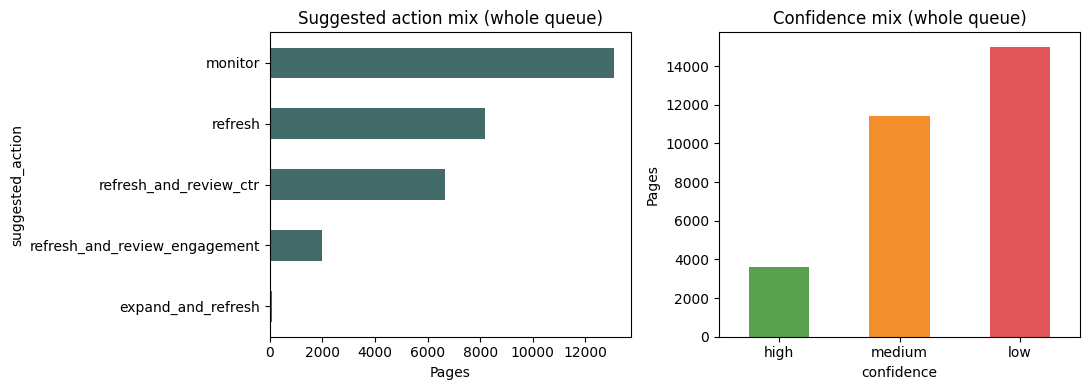

Wrote work/figures/action_playbook_overview.png — commit this to work/figures/.

Monitoring reference stats (kept as a table, not a chart — the units do not share a
comparable scale: a 0-1 rate, a position, and an impression count in the hundreds
would be unreadable on one axis):
  declining_rate: 0.542
  median_avg_position: 10.8
  median_impressions_90d: 731.0
  high_confidence_share: 0.12
  precision_at_50_client_holdout: 0.74


In [13]:
import matplotlib.pyplot as plt

# Figures I will reuse in the paper — these DO get committed (work/figures/), unlike the raw queue.
# Both panels use PAGE COUNTS, so they share a comparable scale (unlike mixing rates,
# positions, and impression counts on one axis, which would be unreadable).
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

action_counts.sort_values().plot(kind="barh", ax=axes[0], color="#426B69")
axes[0].set_title("Suggested action mix (whole queue)")
axes[0].set_xlabel("Pages")

confidence_counts = queue["confidence"].value_counts().reindex(["high", "medium", "low"])
confidence_counts.plot(kind="bar", ax=axes[1], color=["#59A14F", "#F28E2B", "#E15759"], rot=0)
axes[1].set_title("Confidence mix (whole queue)")
axes[1].set_ylabel("Pages")

plt.tight_layout()
fig_path = "work/figures/action_playbook_overview.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Wrote {fig_path} — commit this to work/figures/.")

print()
print("Monitoring reference stats (kept as a table, not a chart — the units do not share a")
print("comparable scale: a 0-1 rate, a position, and an impression count in the hundreds")
print("would be unreadable on one axis):")
for k, v in reference_stats.items():
    print(f"  {k}: {round(v, 3)}")

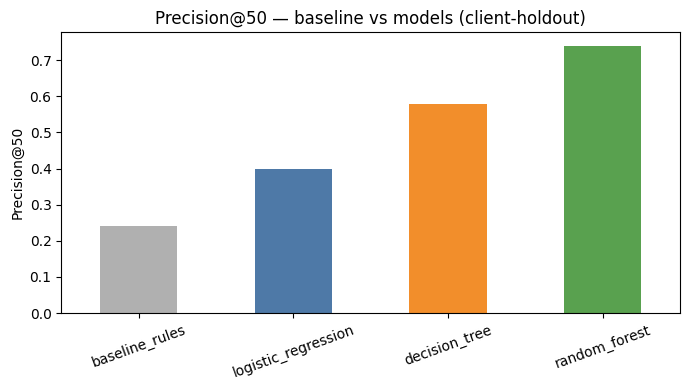

Wrote work/figures/precision_at_50_comparison.png — commit this to work/figures/.

Export summary:
  Queue (gitignored, regenerate on demand): work/outputs/refresh_action_queue.csv
  Receipt JSON (commit):  work/outputs/playbook_summary.json
  Figures (commit):       work/figures/action_playbook_overview.png, work/figures/precision_at_50_comparison.png


In [14]:
fig2, ax2 = plt.subplots(figsize=(7, 4))
comparison = pd.Series({
    "baseline_rules": results["baseline"]["baseline_precision_at_50"],
    "logistic_regression": results["models"]["logistic_regression"]["precision_at_50"],
    "decision_tree": results["models"]["decision_tree"]["precision_at_50"],
    "random_forest": results["models"]["random_forest"]["precision_at_50"],
})
comparison.plot(kind="bar", ax=ax2, color=["#B0B0B0", "#4E79A7", "#F28E2B", "#59A14F"], rot=20)
ax2.set_title("Precision@50 — baseline vs models (client-holdout)")
ax2.set_ylabel("Precision@50")
plt.tight_layout()
fig2_path = "work/figures/precision_at_50_comparison.png"
plt.savefig(fig2_path, dpi=150)
plt.show()
print(f"Wrote {fig2_path} — commit this to work/figures/.")

print("\nExport summary:")
print(f"  Queue (gitignored, regenerate on demand): {queue_export_path}")
print("  Receipt JSON (commit):  work/outputs/playbook_summary.json")
print("  Figures (commit):       work/figures/action_playbook_overview.png, work/figures/precision_at_50_comparison.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.